- **<span style="color: red;">adjusted_points</span>**: It is a measure of how good a cyclist is based on his position, the number of races he participated in, and the points of the race. The average position is not enough because if a cyclist's average position is 2 but he participated in only 1 race, we can't be sure that he is a good cyclist. The same is true for the average position of multiple races: if a cyclist’s average position is 2 and he participated in 30 races, but each race has a low points score, it is different from a top-tier cyclist who participated in 30 races with high scores and has an average position of 2. We also wanted to give a measure of points earned by a cyclist. The formula combines everything in this way: 
<span style="color: yellow;">adjusted_points = points / sqrt(position + 1)</span>
The square root is useful to "decay" the number of points assigned to a cyclist in a non-linear way in order to give a good amount of credit also to the second cyclist, the third etc..

- **<span style="color: red;">BMI</span> (Body Mass Index)**: Calculate BMI for each cyclist using weight and height. This could be correlated with performance metrics, especially on different terrain types or difficulty levels.

- **<span style="color: red;">scaled_position</span>**: Scale the finish position to a [0, 1] range:
<span style="color: yellow;">scaled_position= position−min(position) / max(position)−min(position)</span>

- **<span style="color: red;">scaled_adjusted_points</span>**: It is the same as <span style="color: red;">adjusted_points</span>, but we use <span style="color: red;">scaled_position</span>:
<span style="color: yellow;">scaled_adjusted_points = points / sqrt(scaled_poistion + 1)</span>

- **<span style="color: red;">profile_x_adp</span>**: It is a measure of how good a cyclist is in a given profile. The formula is the same as '<span style="color: red;">adjusted_points</span>', but it is calculated only with respect to the profile of the race. We end up with 5 different features, one for each profile.

- **<span style="color: red;">season_x_adp</span>**: It is a measure of how good a cyclist is in a given season. The formula is the same as '<span style="color: red;">adjusted_points</span>', but it is calculated only with respect to the season of the race. We end up with 4 different features, one for each season.

- **<span style="color: red;">average_position</span>**: Average finish position across all races in which the cyclist participated: This could indicate the cyclist’s general ranking capability, but it favors cyclists who made very few races or easy races and placed in top positions.

- **<span style="color: red;">avg_position_profile_x</span>**: This feature represents the average finish position of a cyclist specifically in races with a given profile. It helps assess how well a cyclist performs in different types of race terrains or conditions, and provides insight into their specialization in certain race profiles.

- **<span style="color: red;">points_std</span>**: Points standard deviation, the standard deviation of the points of the races in which the cyclist participated. A low standard deviation could mean a career made exclusively in the same kind of races.
    
- **<span style="color: red;">position_std</span>**: Position standard deviation, the standard deviation of the position of the cyclist. A low standard deviation could mean a consistent career.
    
- **<span style="color: red;">age_std</span>**: Age standard deviation, the standard deviation of the cyclist's age. A high standard deviation in this case could mean a longer career.

- **<span style="color: red;">average_cyclist_age</span>**: The average age of the cyclist across all the races he made.

- **<span style="color: red;">total_races</span>**: The total number of races in which the cyclist participated.

- **<span style="color: red;">average_profile</span>**: The average race profile of a cyclist, which could be useful for determining the types of races the cyclist has participated in the most. This feature is particularly useful for clustering, as it allows us to group cyclists with similar race characteristics and uncover patterns that might not be visible when looking at individual race results alone.


In [1]:
!pip install "numpy<2"


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip list

Package                   Version
------------------------- -----------
asttokens                 2.4.1
attrs                     24.3.0
colorama                  0.4.6
comm                      0.2.2
contourpy                 1.3.0
cycler                    0.12.1
debugpy                   1.8.6
decorator                 5.1.1
executing                 2.1.0
fastjsonschema            2.21.1
fonttools                 4.54.1
hmmlearn                  0.3.3
imbalanced-learn          0.13.0
imblearn                  0.0
ipykernel                 6.29.5
ipython                   8.28.0
jedi                      0.19.1
joblib                    1.4.2
jsonschema                4.23.0
jsonschema-specifications 2024.10.1
jupyter_client            8.6.3
jupyter_core              5.7.2
kiwisolver                1.4.7
llvmlite                  0.43.0
matplotlib                3.9.2
matplotlib-inline         0.1.7
nbformat                  5.10.4
nest-asyncio              1.6.0
numba              

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import gzip
import numpy as np

In [4]:
with gzip.open('../dataset/filtered_clean_merged_df.pkl', 'r') as file:
    filtered_clean_dataset = pickle.load(file)

In [5]:
filtered_clean_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 441305 entries, 0 to 441670
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   _url_x             441305 non-null  object        
 1   name_x             441305 non-null  object        
 2   birth_year         441305 non-null  int64         
 3   weight             441305 non-null  int64         
 4   height             441305 non-null  int64         
 5   nationality        441305 non-null  object        
 6   race_id            441305 non-null  object        
 7   name_y             441305 non-null  object        
 8   points             441305 non-null  int64         
 9   length             441305 non-null  int64         
 10  profile            441305 non-null  int64         
 11  startlist_quality  441305 non-null  int64         
 12  date               441305 non-null  datetime64[ns]
 13  position           441305 non-null  int64        

In [6]:
cyclists = pd.DataFrame()

# Create seasons:
- Spring : 1
- Summer : 2
- Autumn : 3
- Winter : 4

La primavera boreale corrisponde all'autunno australe: dal 20 marzo al 20 o 21 giugno (93 giorni circa);\
L'estate boreale corrisponde all'inverno australe: dal 20 o 21 giugno al 22 o 23 settembre (94 giorni circa);\
L'autunno boreale corrisponde alla primavera australe: dal 22 o 23 settembre al 21 o 22 dicembre (90 giorni circa);\
L'inverno boreale corrisponde all'estate australe: dal 21 o 22 dicembre al 20 marzo (89 giorni circa).

In [7]:
from utils import map_to_season

# Apply the function to create a new 'season' column
filtered_clean_dataset['season'] = filtered_clean_dataset['month_day'].apply(map_to_season)

filtered_clean_dataset.head()

,_url_x,name_x,birth_year,weight,height,nationality,race_id,name_y,points,length,...,startlist_quality,date,position,cyclist,cyclist_age,is_tarmac,delta,year,month_day,season
0,gerard-rue,Gérard Rué,1965,74,182,France,tour-de-france/1997/stage-2,Tour de France,100,262000,...,1994,1997-07-07 06:27:47,132,gerard-rue,32,True,0,1997,07-07,2
1,gerard-rue,Gérard Rué,1965,74,182,France,tour-de-france/1990/stage-1,Tour de France,100,138500,...,1959,1990-07-01 03:29:36,66,gerard-rue,25,True,635,1990,07-01,2
2,gerard-rue,Gérard Rué,1965,74,182,France,tour-de-france/1992/stage-7,Tour de France,100,196500,...,2047,1992-07-11 04:22:52,35,gerard-rue,27,True,65,1992,07-11,2
3,gerard-rue,Gérard Rué,1965,74,182,France,tour-de-france/1990/stage-9,Tour de France,100,196000,...,1959,1990-07-09 04:46:44,41,gerard-rue,25,True,37,1990,07-09,2
4,gerard-rue,Gérard Rué,1965,74,182,France,tour-de-france/1991/stage-12,Tour de France,100,192000,...,1933,1991-07-18 05:22:47,10,gerard-rue,26,True,415,1991,07-18,2


Let's see the amount of races by each season

In [8]:
unique_races = filtered_clean_dataset.drop_duplicates(subset='race_id')

circuits_for_season = unique_races['season'].value_counts(normalize=True) * 100

circuits_for_season = pd.DataFrame({'season':circuits_for_season.index, 'percentage':circuits_for_season.values})
circuits_for_season['percentage'][0]
print(f"spring: {circuits_for_season['percentage'][0]}")
print(f"summer: {circuits_for_season['percentage'][1]}")
print(f"autumn: {circuits_for_season['percentage'][2]}")
print(f"winter: {circuits_for_season['percentage'][3]}")



spring: 44.285714285714285
summer: 39.44250871080139
autumn: 14.425087108013937
winter: 1.8466898954703832


Let'see explore some races and see the usual period they are made

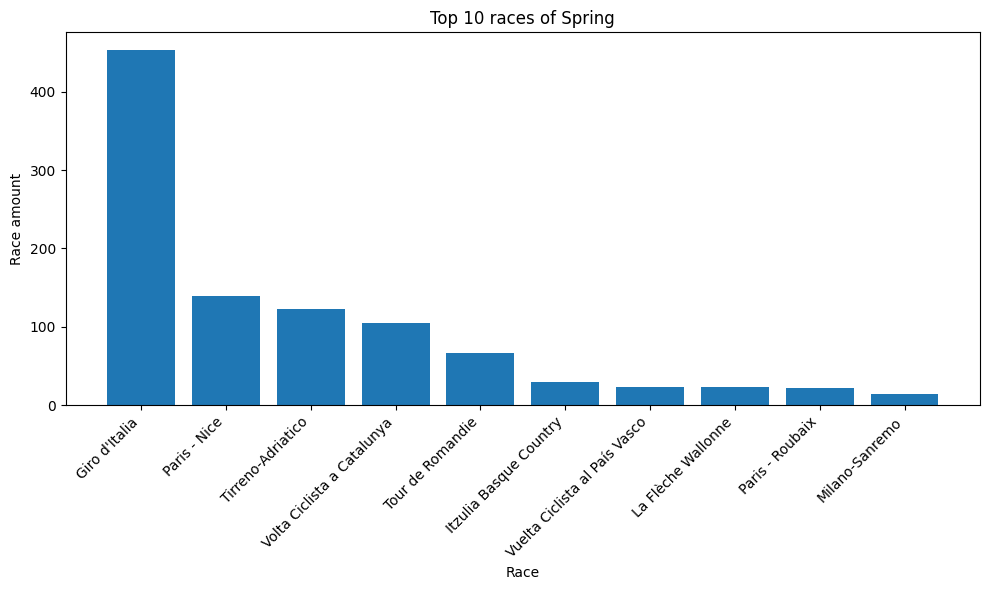

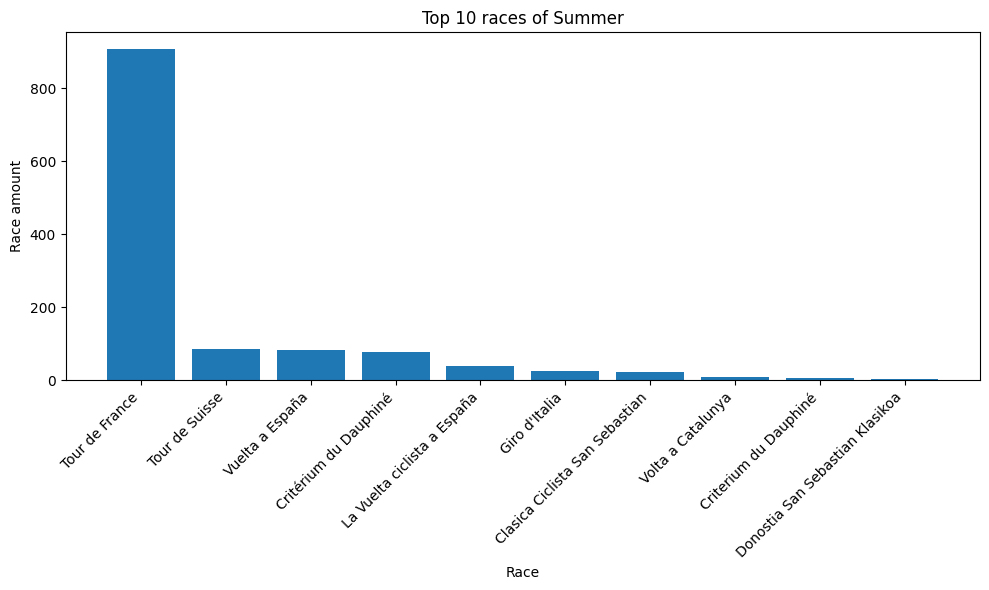

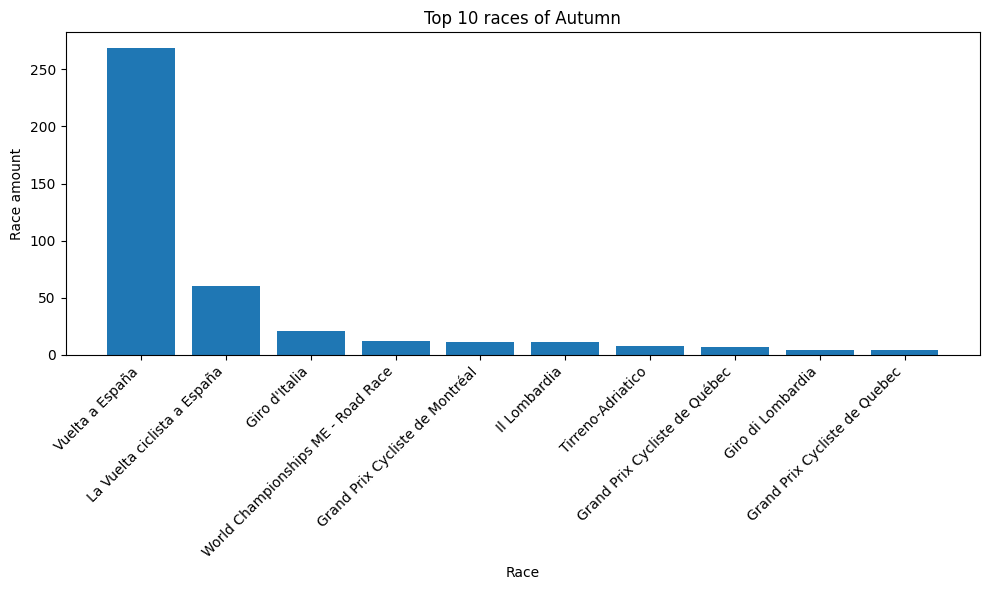

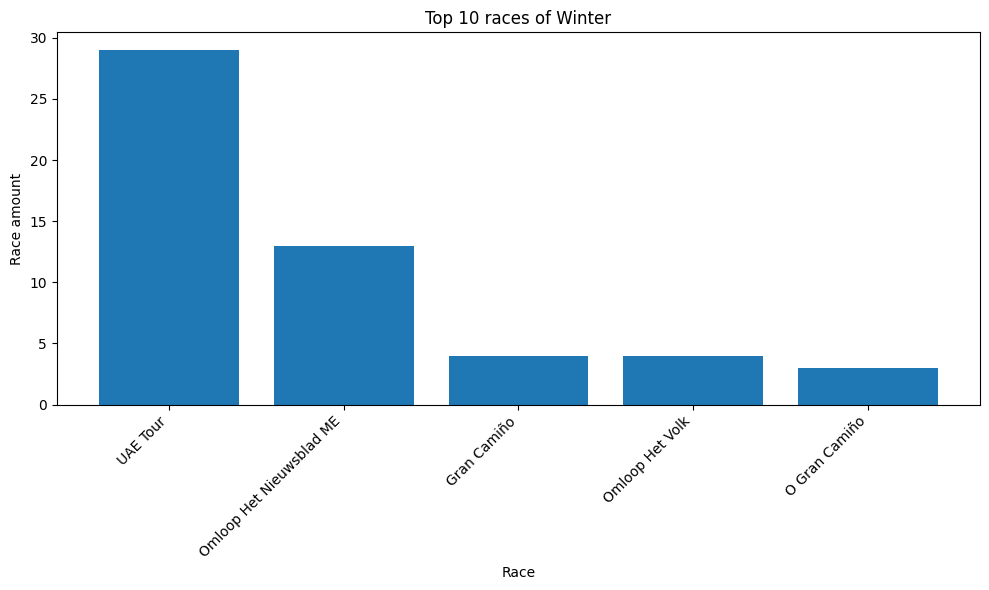

In [9]:
top_k = 10
seasons = {
    1: 'Spring',
    2: 'Summer',
    3: 'Autumn',
    4: 'Winter'
}

for i in range(1,5):
    season = filtered_clean_dataset[filtered_clean_dataset['season'] == i]
    season = season.drop_duplicates(subset='race_id')
    races_counts = season.groupby('name_y').size().reset_index(name='races_amount')
    races_counts = races_counts.sort_values(by='races_amount', ascending=False)

    top = races_counts.head(top_k)
    plt.figure(figsize=(10, 6))
    plt.bar(top['name_y'], top['races_amount'])
    plt.title(f'Top {top_k} races of {seasons[i]}')
    plt.xlabel('Race')
    plt.ylabel('Race amount')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

From what we can see from the plots:
- Giro d'italia is made in Spring
- Tour de France is made in Autumn
- Vuelta d'espana is a strange one, because it appears in 3 different seasons, but according to wikipedia: 'It was originally held in the spring, usually late April, with a few editions held in June in the 1940s. In 1995, however, the race moved to September to avoid direct competition with the Giro d'Italia, held in May.' That's why it appears in multiple seasons.

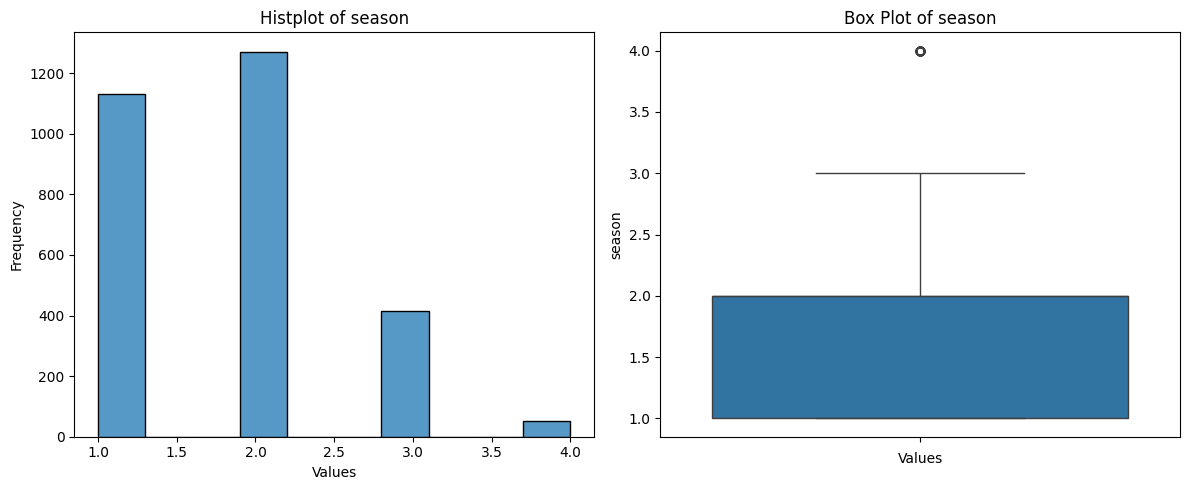

In [10]:
from utils import box_hist_plot

box_hist_plot(columns_to_select=['season'],
              dataset=unique_races,
              n_bins=10,
              kde=False)

- Create the features we discussed at the start of the file.

In [11]:
# calculate the adjusted points per race using the formula -> points / sqrt(position + 1)
filtered_clean_dataset['adjusted_points'] = filtered_clean_dataset['points'] / np.sqrt(filtered_clean_dataset['position'] + 1)

# Normalize position by dividing it by points or startlist_quality, 
# which gives a relative position score that accounts for race prestige or difficulty.
filtered_clean_dataset['normalized_position_points'] = filtered_clean_dataset['position'] / filtered_clean_dataset['points']
filtered_clean_dataset['normalized_position_startlist'] = filtered_clean_dataset['position'] / filtered_clean_dataset['startlist_quality']

filtered_clean_dataset['scaled_position'] = filtered_clean_dataset.groupby('race_id')['position'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

filtered_clean_dataset['scaled_adjusted_points'] = filtered_clean_dataset['points'] / np.sqrt(filtered_clean_dataset['scaled_position'] + 1)

# Create body mass index weight/(height*100)^2
filtered_clean_dataset['bmi'] = filtered_clean_dataset['weight'] / ((filtered_clean_dataset['height']/100) **2)

In [12]:
# create cyclists dataset, start from the features we had or the features we created now and make the average or the sum
cyclists = filtered_clean_dataset.groupby('cyclist').agg({
    'birth_year': 'first',
    'bmi': 'first',
    'cyclist_age': 'mean',
    'adjusted_points': 'sum',
    'scaled_adjusted_points': 'sum',
    'position': 'mean',
    'profile': 'mean',
    'normalized_position_points': 'mean',
    'normalized_position_startlist': 'mean',
}).reset_index()

# change some names for easier understanding
cyclists.rename(columns={'profile': 'average_profile'}, inplace=True)
cyclists.rename(columns={'cyclist_age': 'average_cyclist_age'}, inplace=True)
cyclists.rename(columns={'normalized_position_points': 'average_normalized_position_points'}, inplace=True)
cyclists.rename(columns={'normalized_position_startlist': 'average_normalized_position_startlist'}, inplace=True)
cyclists.rename(columns={'position': 'average_position'}, inplace=True)


- Creation of the "profiles" (flat,hilly..)

In [13]:
# Calculate profile distribution ratios: for each cyclist create 5 different profile ratios, a cyclist who made mostly flat races 
# could have a division for each profile like this: 70% / 10% / 10% / 5% / 5%
profile_counts_5 = filtered_clean_dataset.groupby(['cyclist', 'profile']).size().unstack(fill_value=0)
# profile_counts_3 = filtered_clean_dataset.groupby(['cyclist', 'profile']).size().unstack(fill_value=0)

# Calculate the total number of races per cyclist for normalization
profile_counts_5['total_races'] = profile_counts_5.sum(axis=1)

# Calculate the profile distribution ratios
for profile in profile_counts_5.columns[:-1]:
    profile_counts_5[f'profile_{profile}_ratio'] = profile_counts_5[profile] / profile_counts_5['total_races'] * 100

# Calculate a weighted average profile score, emphasizing higher frequencies
filtered_clean_dataset['weighted_profile'] = filtered_clean_dataset['profile']
weighted_profile_score = filtered_clean_dataset.groupby('cyclist').agg(
    weighted_profile=('weighted_profile', 'mean')
).reset_index()

profile_counts_5 = profile_counts_5.reset_index()

In [14]:
cyclists = pd.merge(cyclists, profile_counts_5[['cyclist', 'total_races']], on='cyclist', how='left')

- Create seasons adjusted points (spring,summer,autumn,winter)

In [15]:
grouped = filtered_clean_dataset.groupby(['cyclist', 'season'])['adjusted_points'].sum().reset_index()
season_x_adp = grouped.pivot(index='cyclist', columns='season', values='adjusted_points')
season_x_adp.columns = [f'season_{int(col)}_adp' for col in season_x_adp.columns]

In [16]:
cyclists = pd.merge(cyclists, season_x_adp, on='cyclist', how='left')

- Create average position for each profile

In [17]:
avg_positions = filtered_clean_dataset.groupby(['cyclist', 'profile'])['position'].mean().reset_index()
pivot_df = avg_positions.pivot(index='cyclist', columns='profile', values='position')
pivot_df.columns = [f'avg_position_profile_{col}' for col in pivot_df.columns]
cyclists = cyclists.merge(pivot_df, on='cyclist', how='left')

- Create standard deviation features (points_std, position_std, cyclist_age_std)

In [18]:
# standard deviation of the position and points, a cyclist with less standard deviation is more consistent
std_dev = filtered_clean_dataset.groupby('cyclist').agg({
    'cyclist_age': 'std',
    'position': 'std',
    'points': 'std'
}).reset_index()

std_dev.rename(columns={'position': 'position_std', 'points': 'points_std', 'cyclist_age': 'cycist_age_std'}, inplace=True)
cyclists = pd.merge(cyclists, std_dev, on='cyclist')


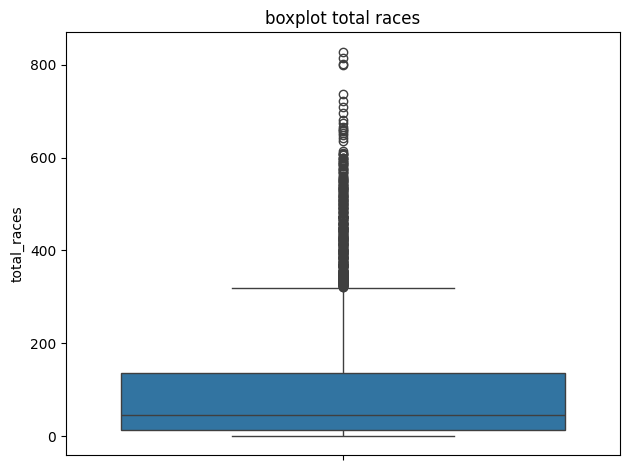

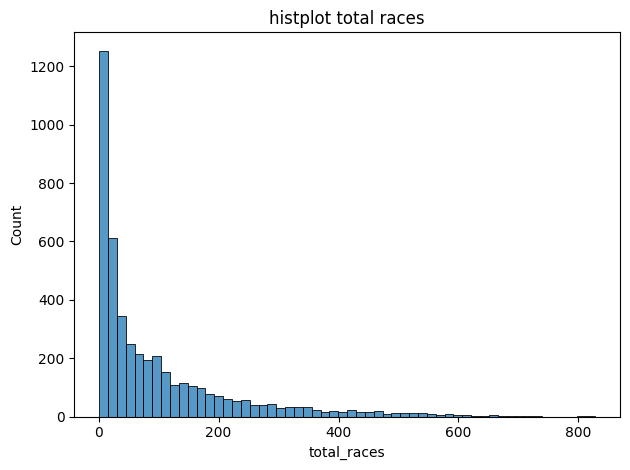

In [19]:
plt.figure()
plt.title("boxplot total races")
sns.boxplot(cyclists['total_races'])
plt.tight_layout()
plt.show()

plt.figure()
plt.title("histplot total races")
sns.histplot(cyclists['total_races'])
plt.tight_layout()
plt.show()

In [20]:
# Print amount of cyclists with 600+ races
high_race_cyclists = cyclists[cyclists['total_races'] >= 600]
len(high_race_cyclists)

23

In [21]:
# Print amount of cyclists with 1 race
one_race_cyclists = cyclists[cyclists['total_races'] <= 1]
len(one_race_cyclists)

348

- We have a lot of cyclists who made very few races, and very few cyclists who made a lot. Only 31 made +600 races and 446 made only 1 race.
- Let's see what happens if we put a threshold on min/max amount of races.

In [22]:
threshold_down = 10
threshold_up = 600

# Filter out records with 'points' below the threshold
cyclists_threshold = cyclists[(cyclists['total_races'] >= threshold_down) & (cyclists['total_races'] <= threshold_up)]

In [23]:
cyclists_threshold.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3496 entries, 0 to 4476
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   cyclist                                3496 non-null   object 
 1   birth_year                             3496 non-null   int64  
 2   bmi                                    3496 non-null   float64
 3   average_cyclist_age                    3496 non-null   float64
 4   adjusted_points                        3496 non-null   float64
 5   scaled_adjusted_points                 3496 non-null   float64
 6   average_position                       3496 non-null   float64
 7   average_profile                        3496 non-null   float64
 8   average_normalized_position_points     3496 non-null   float64
 9   average_normalized_position_startlist  3496 non-null   float64
 10  total_races                            3496 non-null   int64  
 11  season_1_

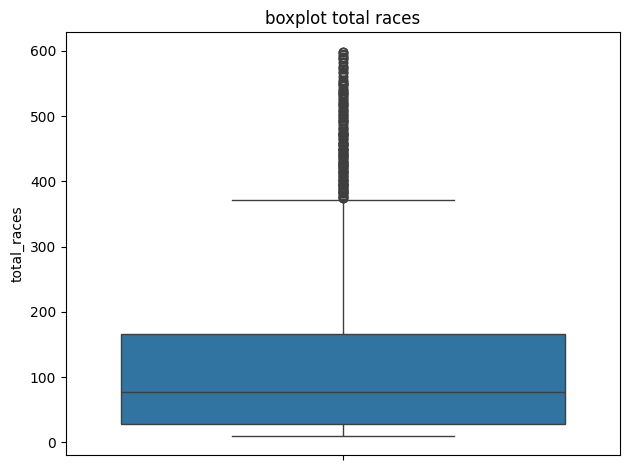

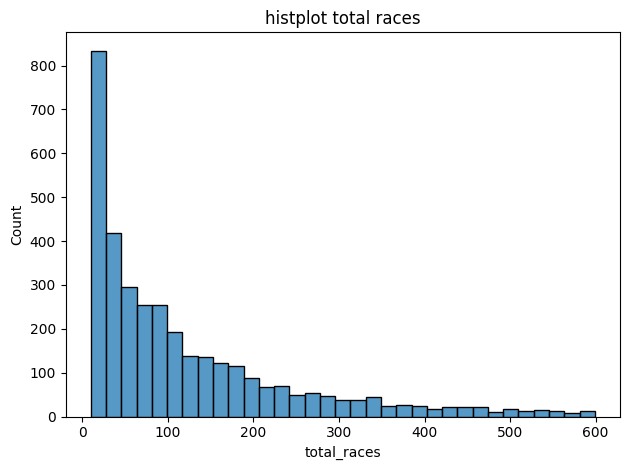

In [24]:
plt.figure()
plt.title("boxplot total races")
sns.boxplot(cyclists_threshold['total_races'])
plt.tight_layout()
plt.show()

plt.figure()
plt.title("histplot total races")
sns.histplot(cyclists_threshold['total_races'])
plt.tight_layout()
plt.show()

- If we put a threshold we quite a lot of cyclists depending on the threshold, so for the moment avoid using threshold.

In [25]:
cyclists.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4477 entries, 0 to 4476
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   cyclist                                4477 non-null   object 
 1   birth_year                             4477 non-null   int64  
 2   bmi                                    4477 non-null   float64
 3   average_cyclist_age                    4477 non-null   float64
 4   adjusted_points                        4477 non-null   float64
 5   scaled_adjusted_points                 4477 non-null   float64
 6   average_position                       4477 non-null   float64
 7   average_profile                        4477 non-null   float64
 8   average_normalized_position_points     4477 non-null   float64
 9   average_normalized_position_startlist  4477 non-null   float64
 10  total_races                            4477 non-null   int64  
 11  seas

- Impute season_x_adp with 0 where is null (it is safe and reasonable because if a cyclist never did a race in a certain season his score is 0). 

In [26]:
columns_to_impute = ['season_1_adp', 'season_2_adp', 'season_3_adp', 'season_4_adp']

# Fill null values with 0 for specified columns
cyclists[columns_to_impute] = cyclists[columns_to_impute].fillna(0)

# Check the result
print(cyclists[columns_to_impute].isnull().sum())  # Should print 0 for all columns


season_1_adp    0
season_2_adp    0
season_3_adp    0
season_4_adp    0
dtype: int64


In [27]:
cyclists.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4477 entries, 0 to 4476
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   cyclist                                4477 non-null   object 
 1   birth_year                             4477 non-null   int64  
 2   bmi                                    4477 non-null   float64
 3   average_cyclist_age                    4477 non-null   float64
 4   adjusted_points                        4477 non-null   float64
 5   scaled_adjusted_points                 4477 non-null   float64
 6   average_position                       4477 non-null   float64
 7   average_profile                        4477 non-null   float64
 8   average_normalized_position_points     4477 non-null   float64
 9   average_normalized_position_startlist  4477 non-null   float64
 10  total_races                            4477 non-null   int64  
 11  seas

- If we drop null rows we end up with 3202 cyclists.

In [28]:
cyclists.dropna().info()

<class 'pandas.core.frame.DataFrame'>
Index: 3037 entries, 0 to 4476
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   cyclist                                3037 non-null   object 
 1   birth_year                             3037 non-null   int64  
 2   bmi                                    3037 non-null   float64
 3   average_cyclist_age                    3037 non-null   float64
 4   adjusted_points                        3037 non-null   float64
 5   scaled_adjusted_points                 3037 non-null   float64
 6   average_position                       3037 non-null   float64
 7   average_profile                        3037 non-null   float64
 8   average_normalized_position_points     3037 non-null   float64
 9   average_normalized_position_startlist  3037 non-null   float64
 10  total_races                            3037 non-null   int64  
 11  season_1_

<Axes: title={'center': 'kendall correlation'}>

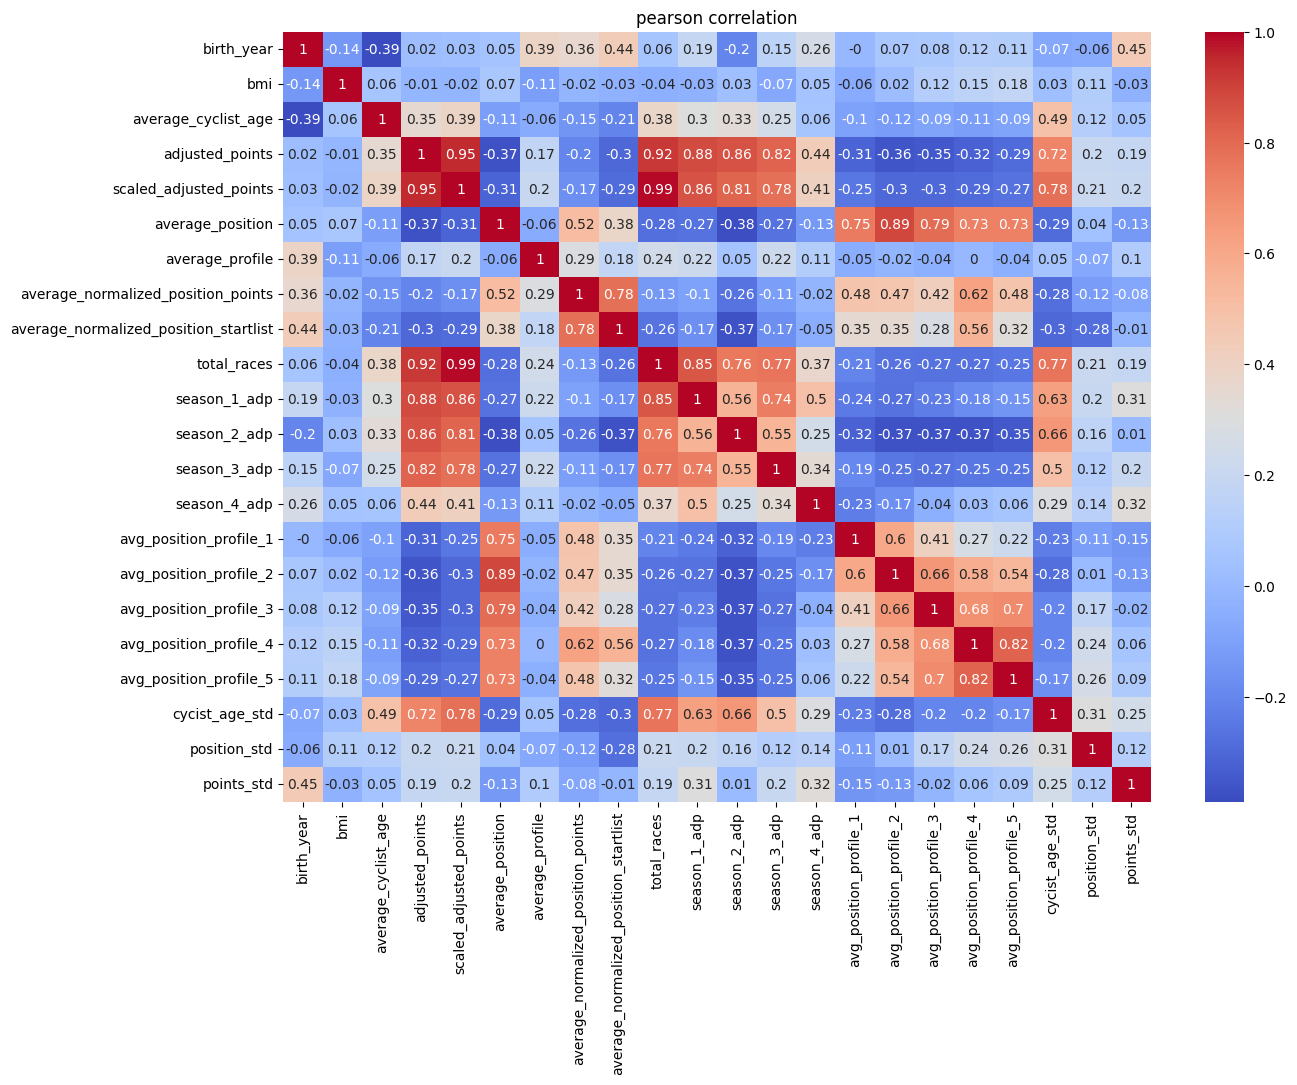

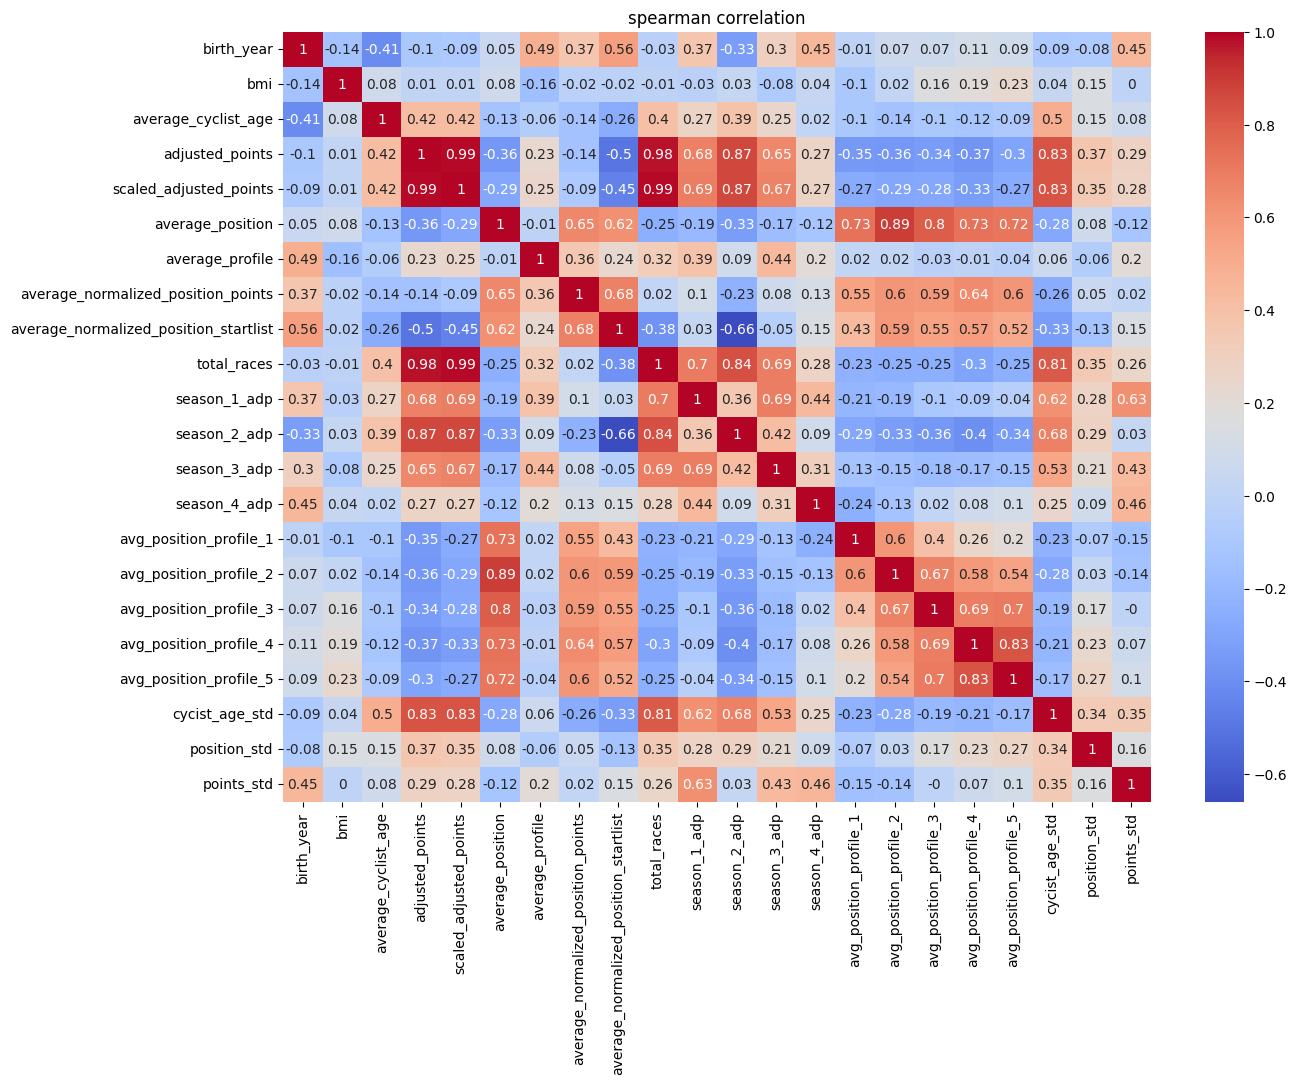

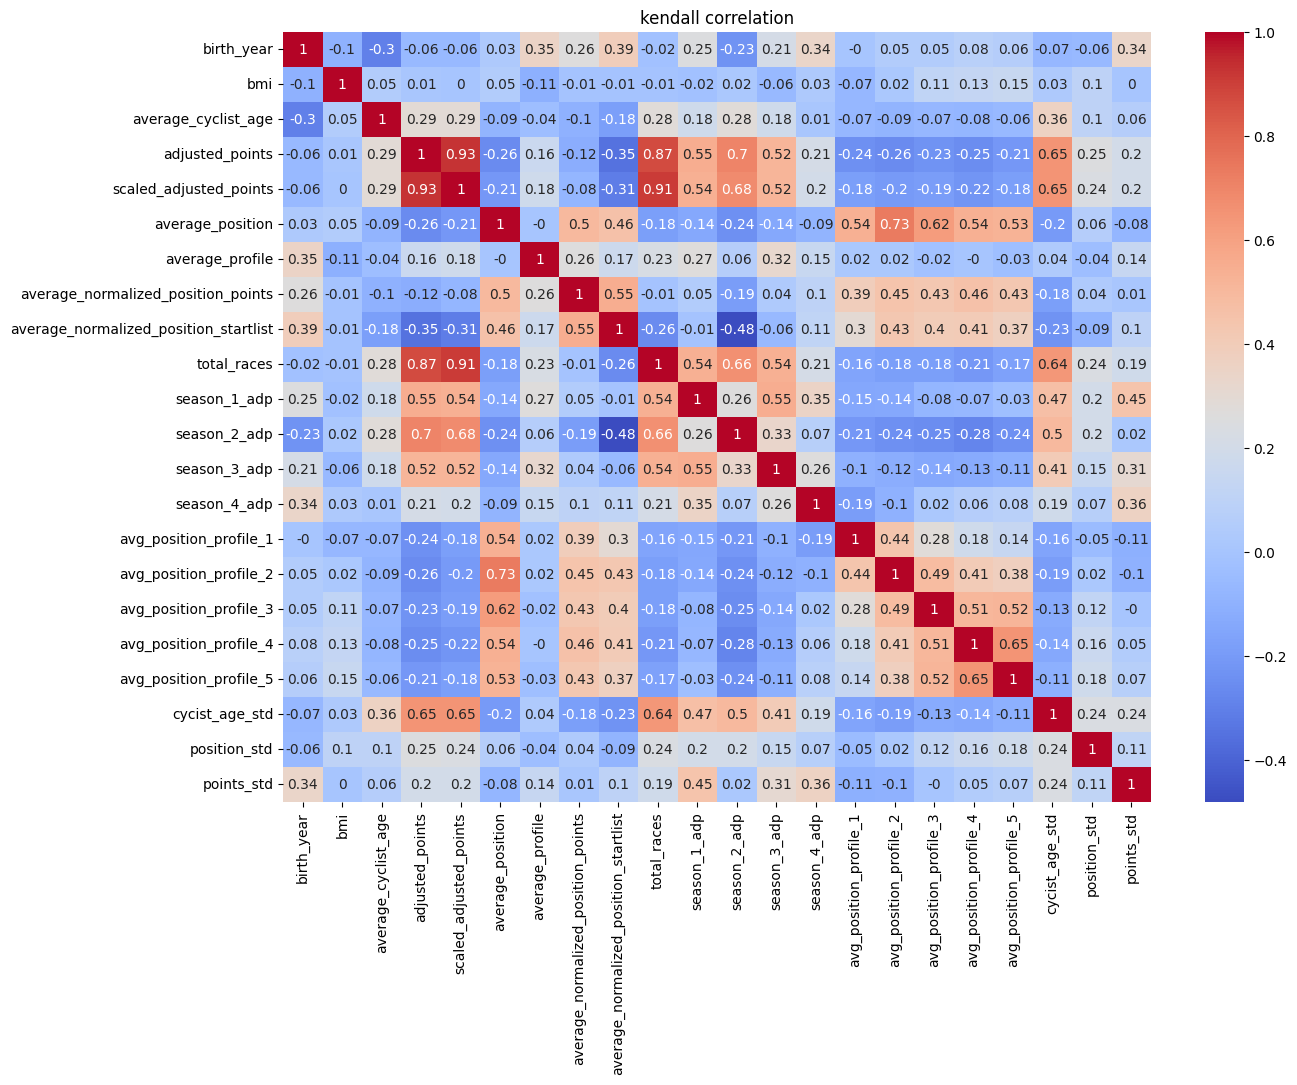

In [29]:
cyclists_numerical = cyclists.select_dtypes(include=[float, int])

correlation = cyclists_numerical.corr('pearson')

plt.figure(figsize=(14, 10))
plt.title('pearson correlation')

sns.heatmap(correlation.round(2),annot=True, cmap='coolwarm')

correlation = cyclists_numerical.corr('spearman')

plt.figure(figsize=(14, 10))
plt.title('spearman correlation')
sns.heatmap(correlation.round(2),annot=True, cmap='coolwarm')

correlation = cyclists_numerical.corr('kendall')

plt.figure(figsize=(14, 10))
plt.title('kendall correlation')

sns.heatmap(correlation.round(2),annot=True, cmap='coolwarm')

- Visualize new features with histograms and boxplots.

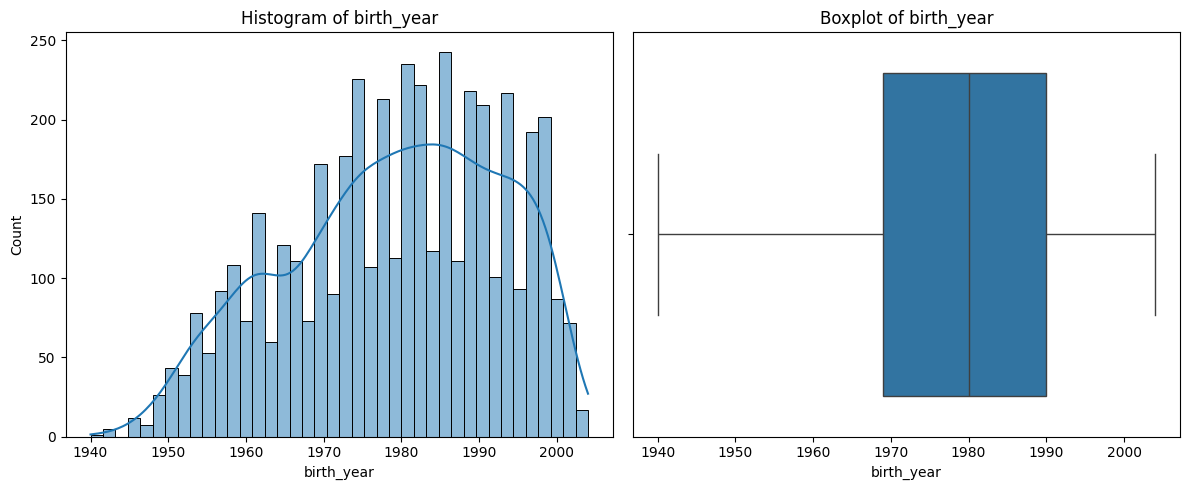

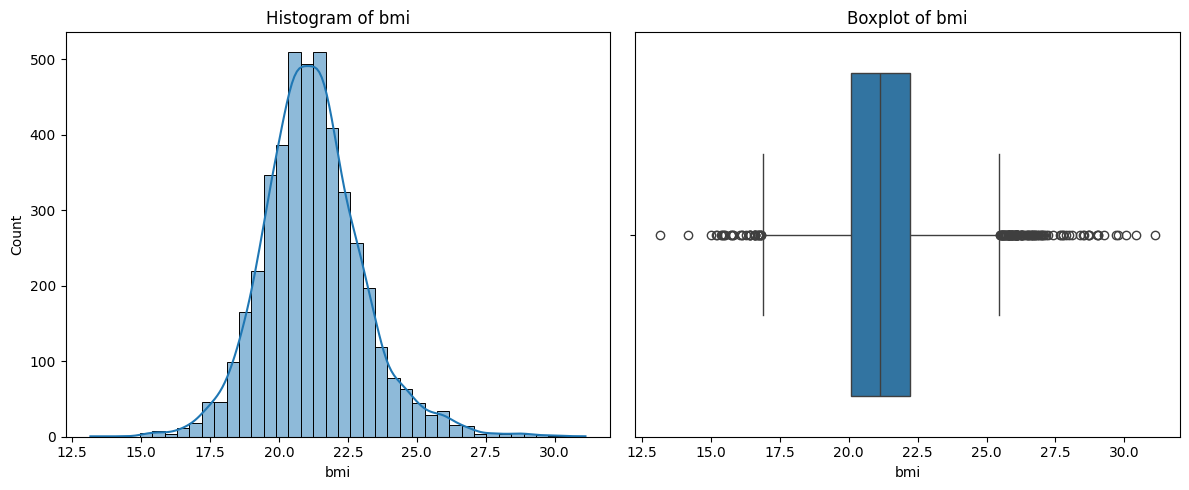

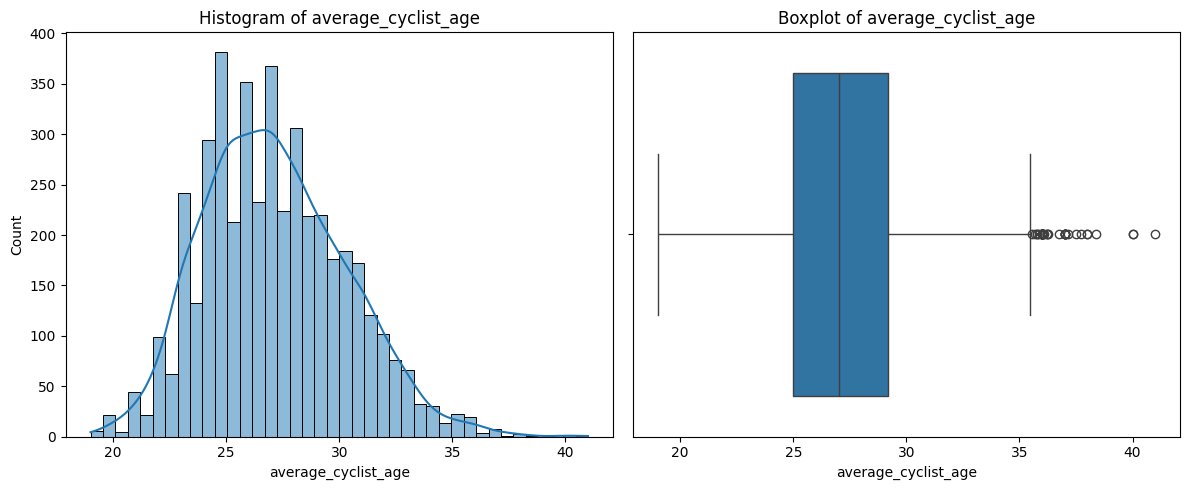

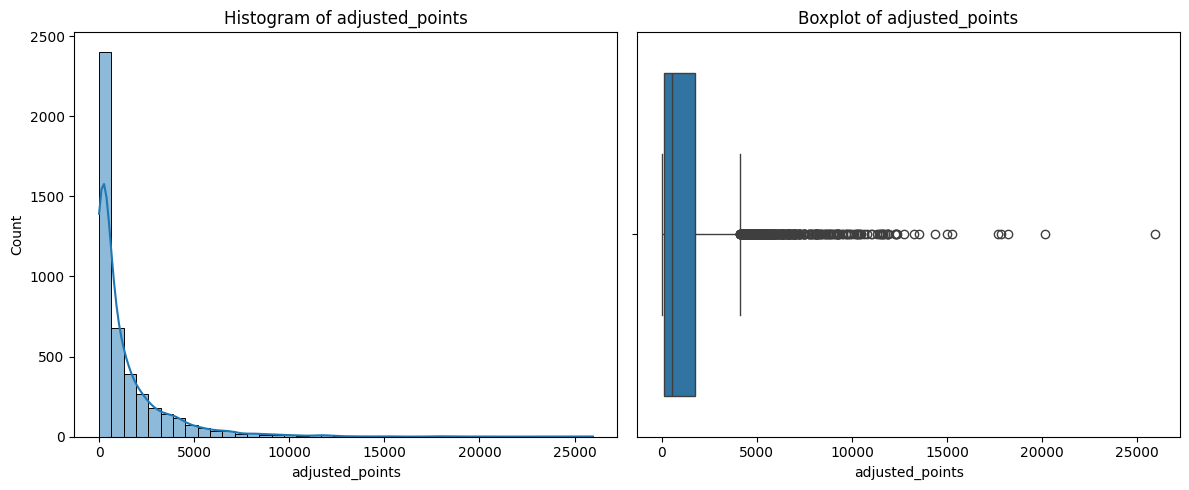

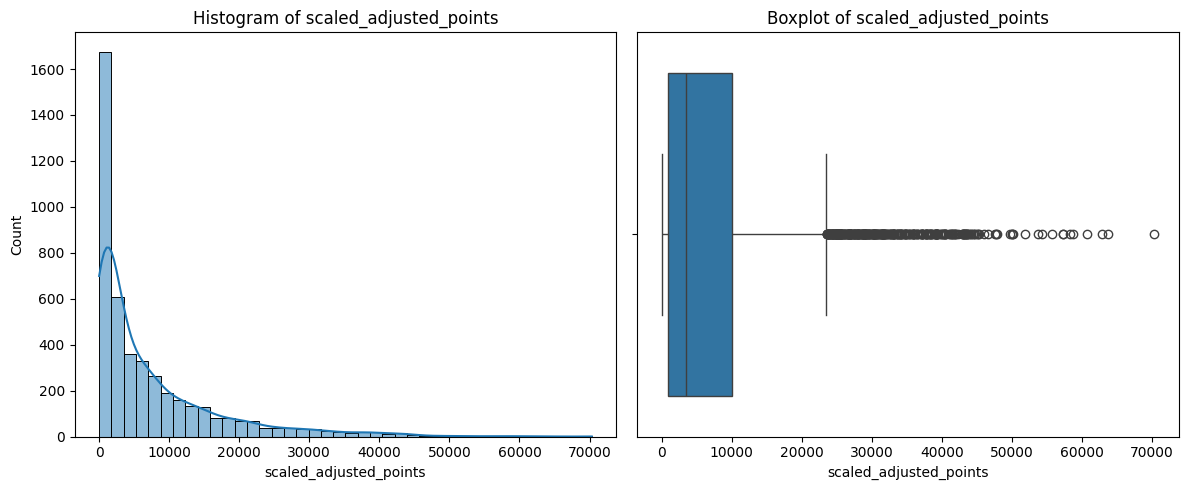

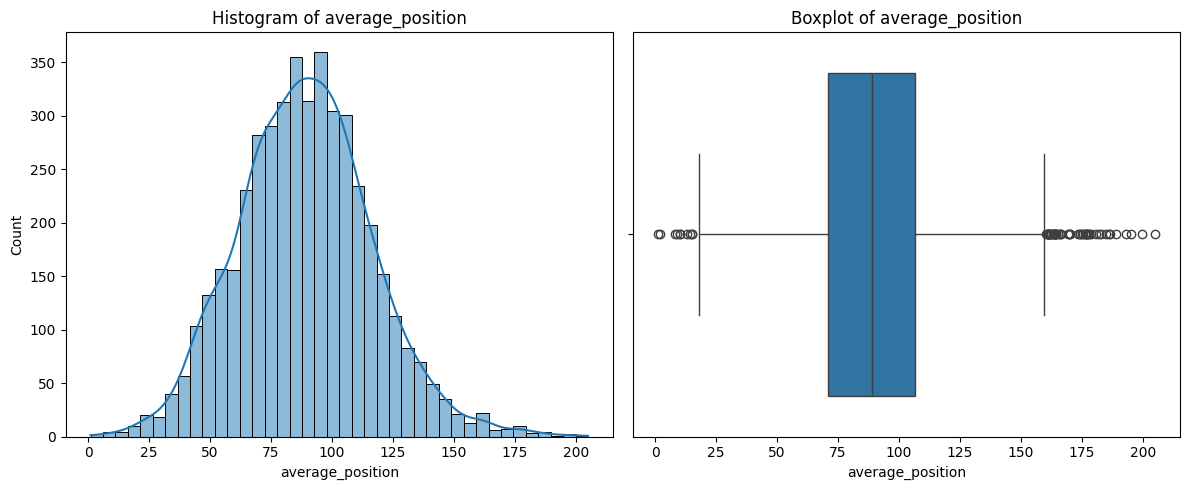

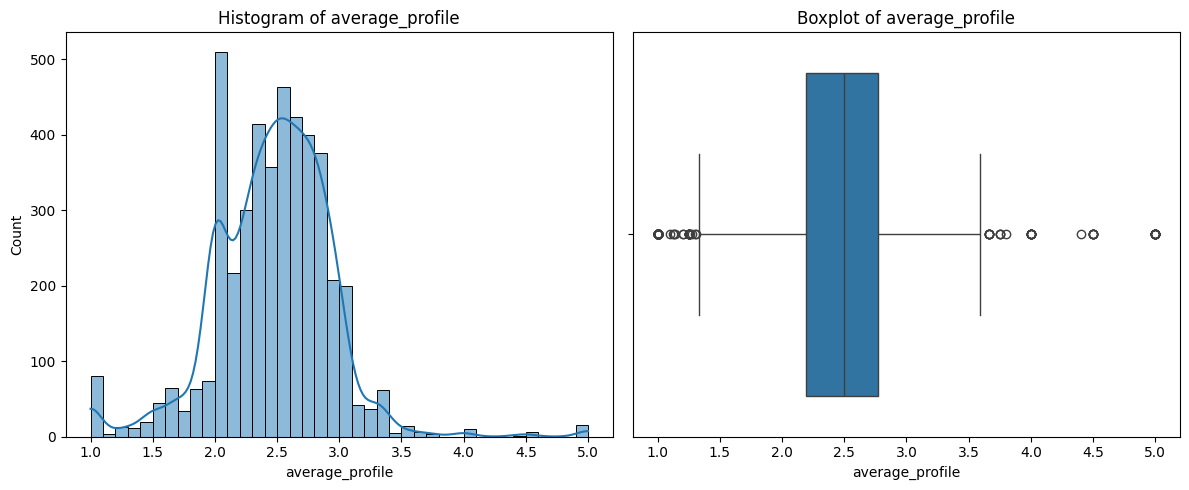

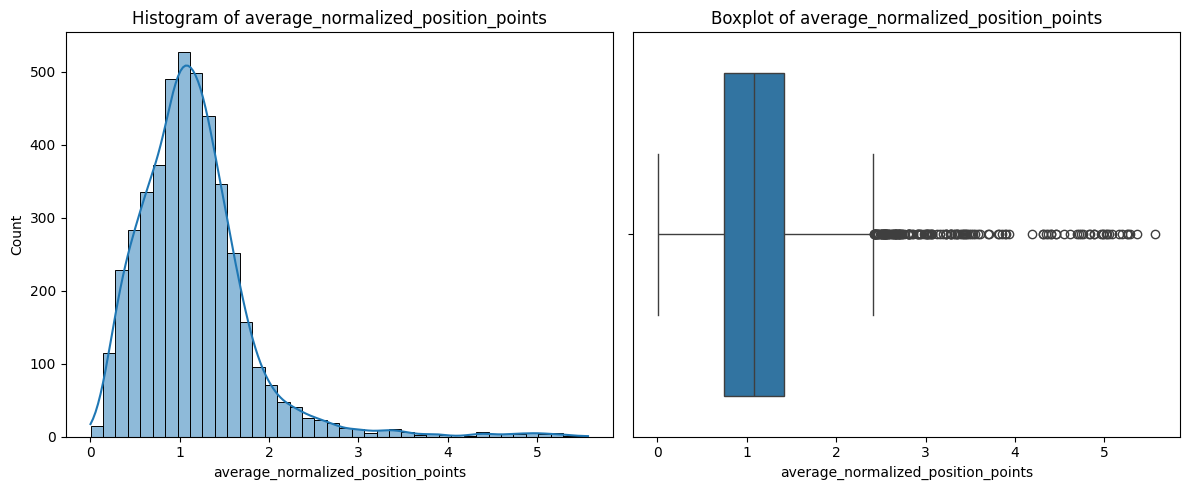

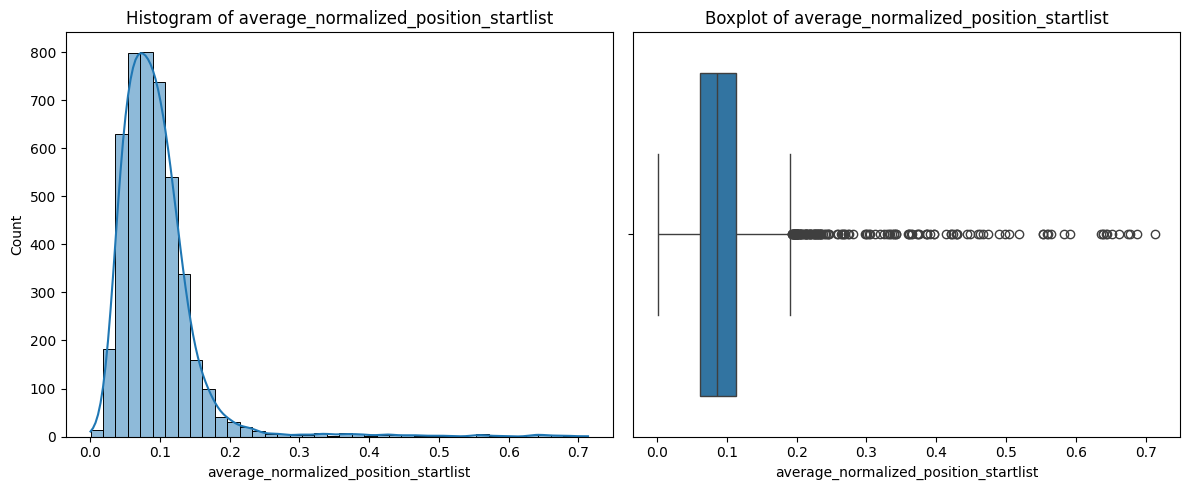

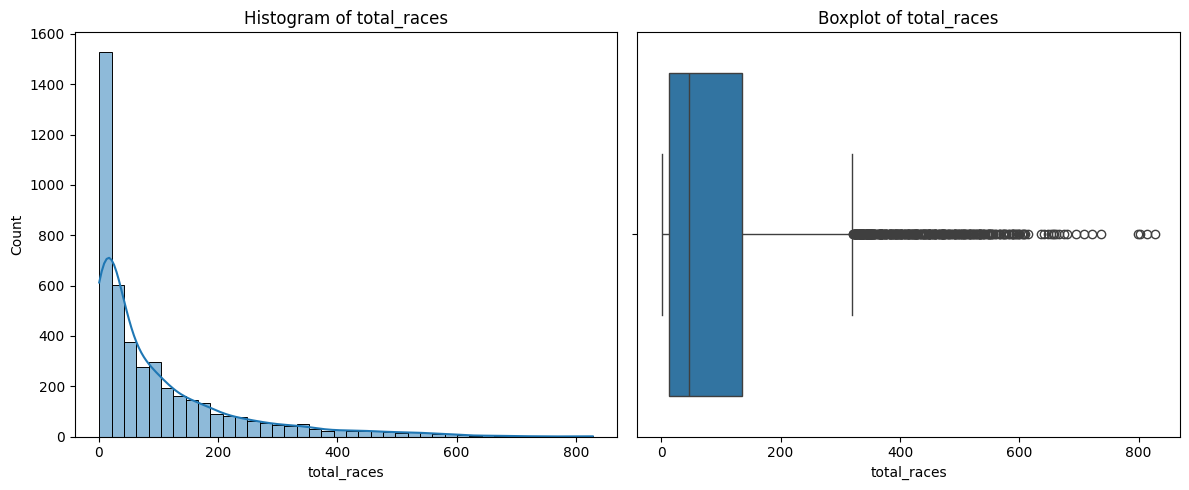

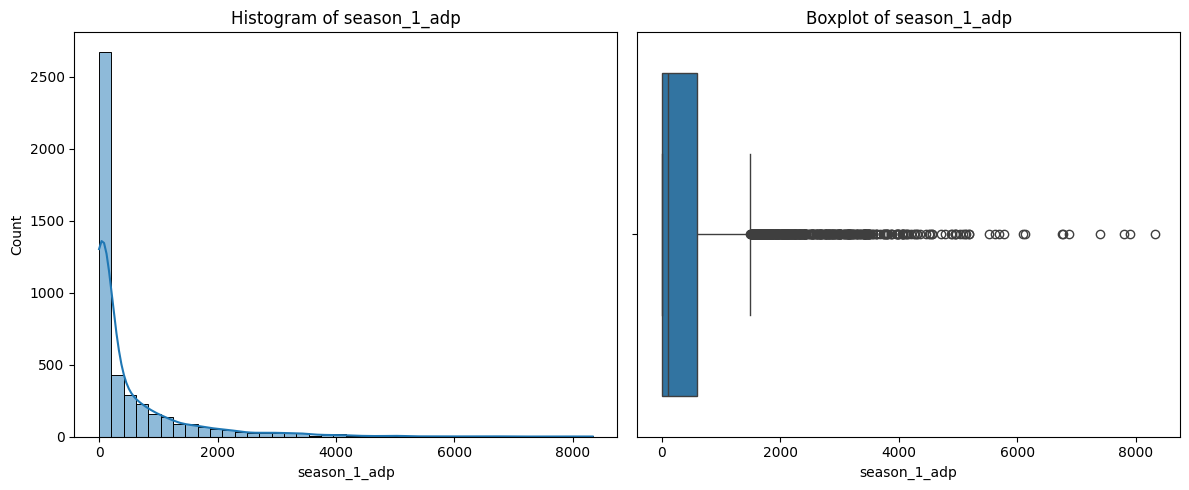

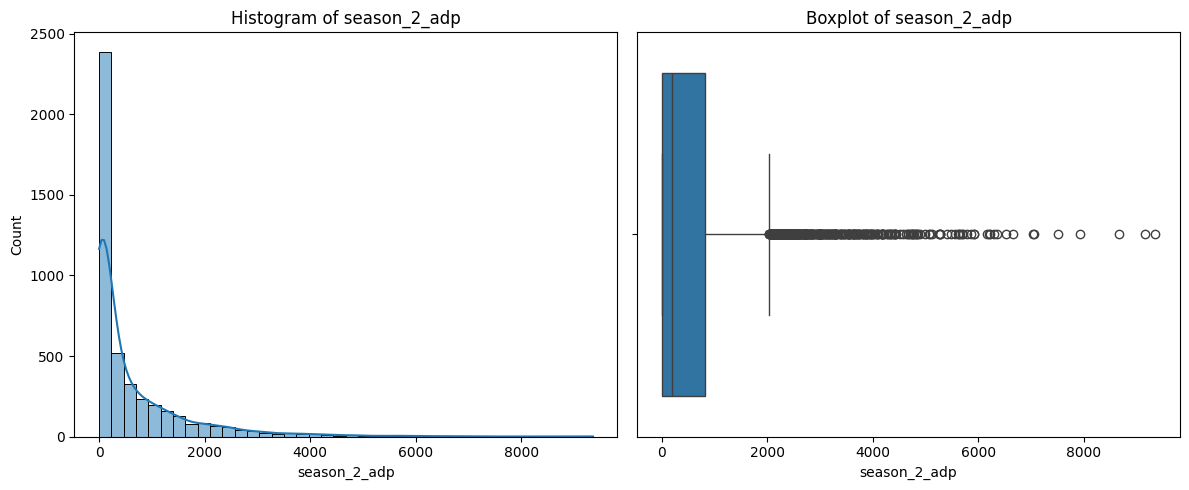

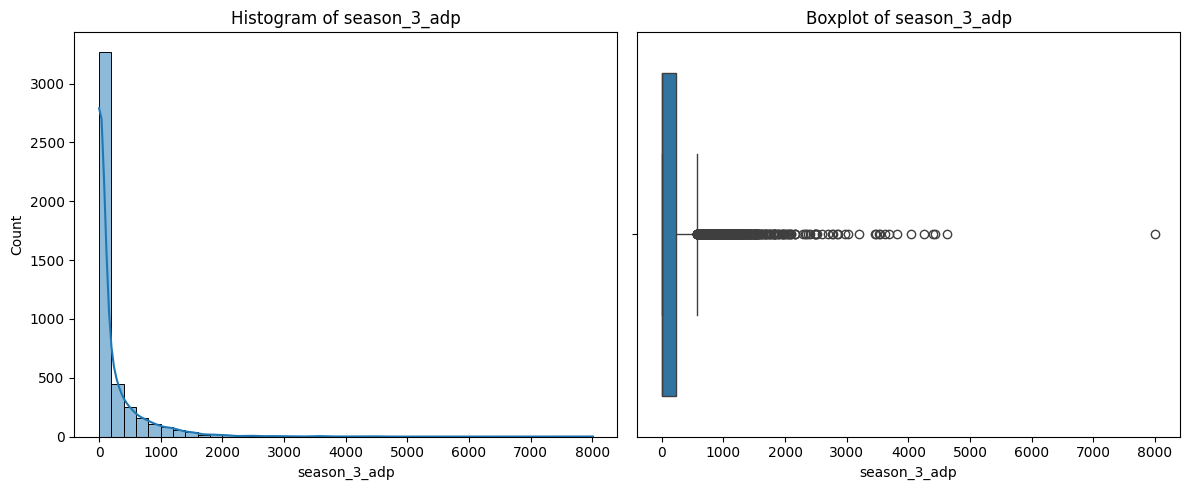

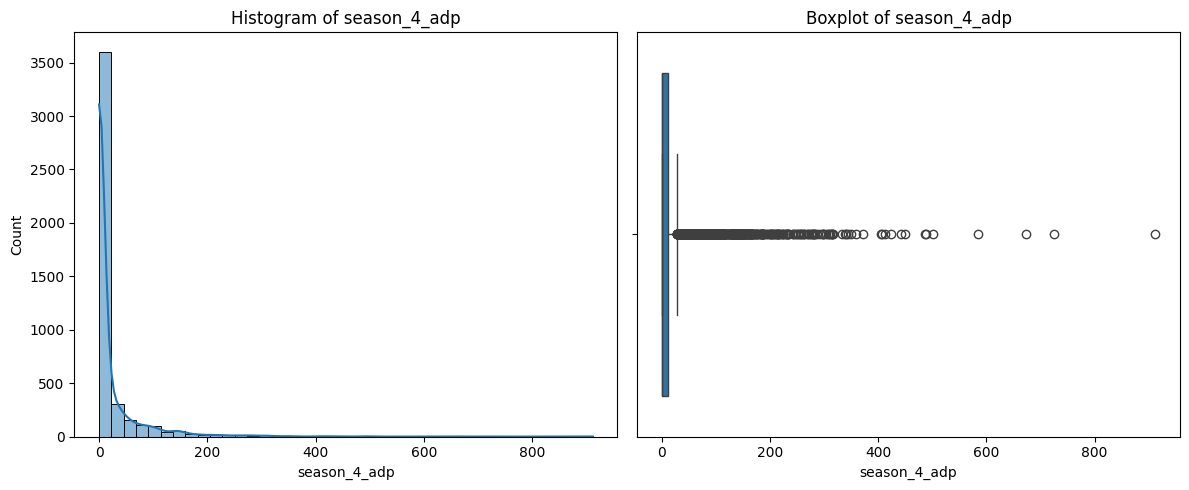

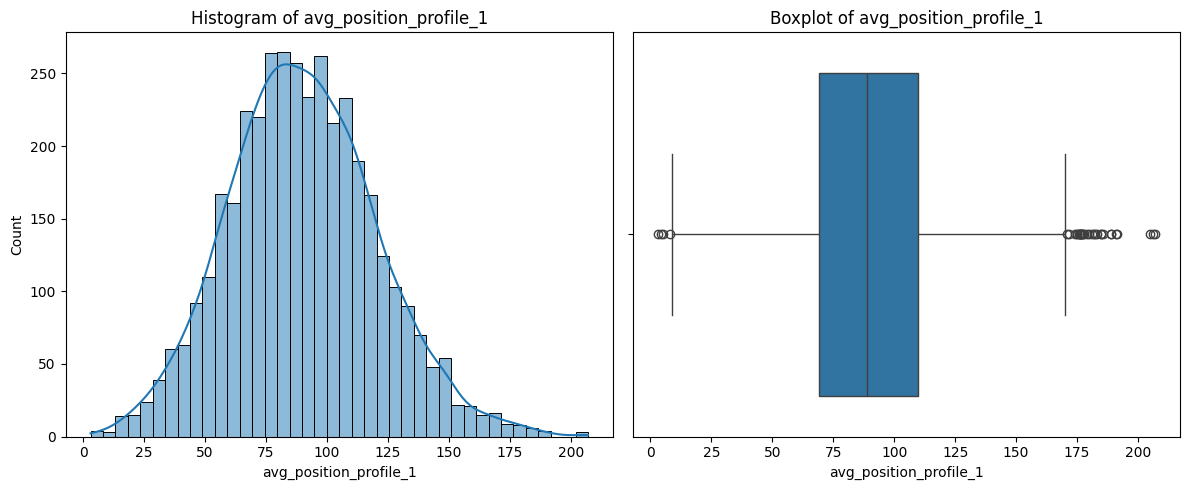

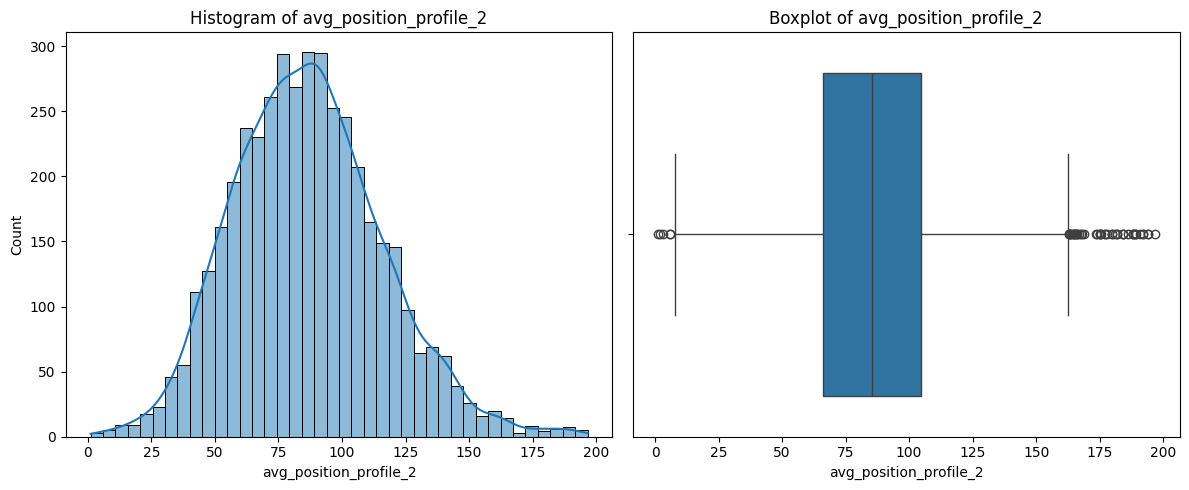

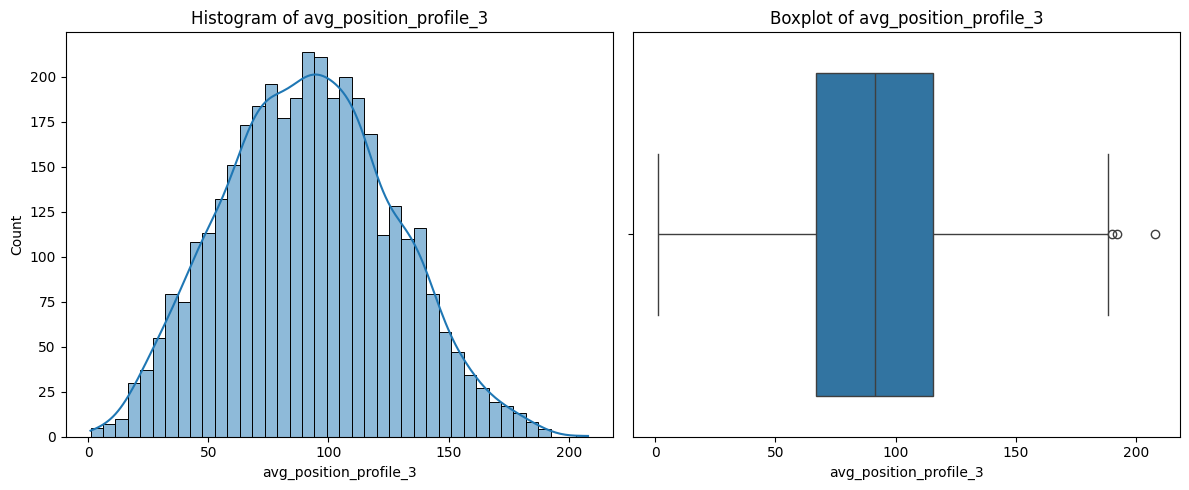

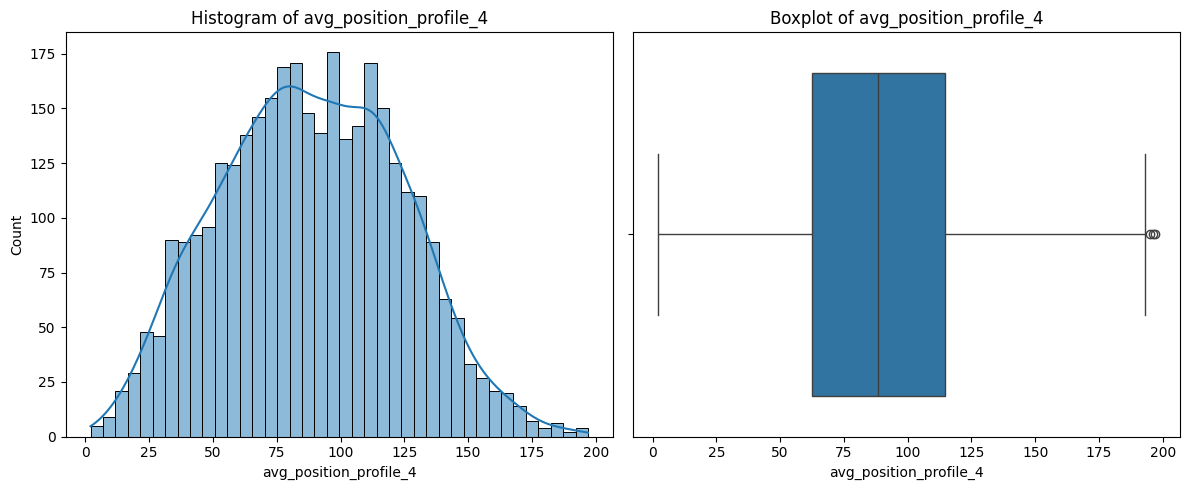

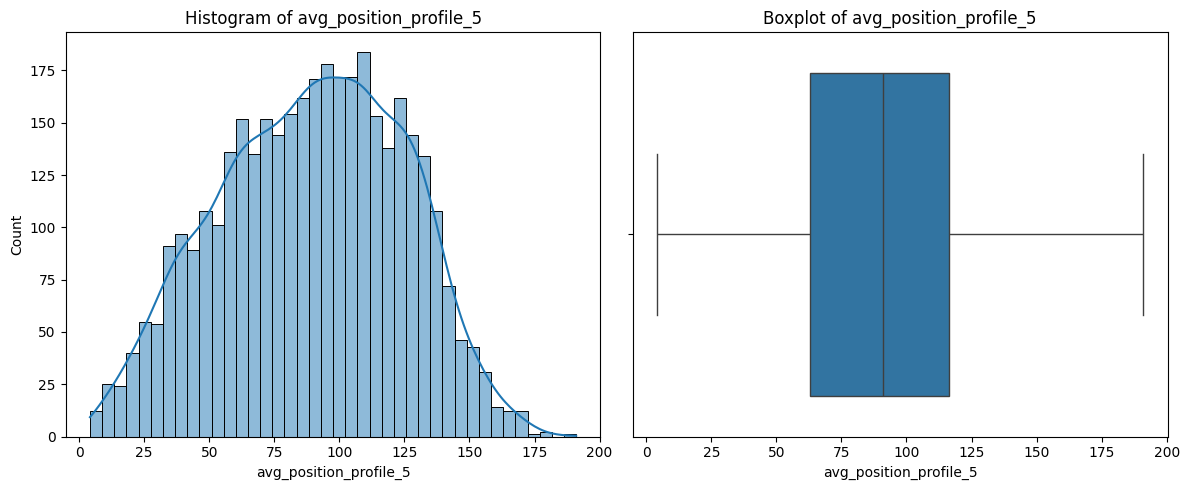

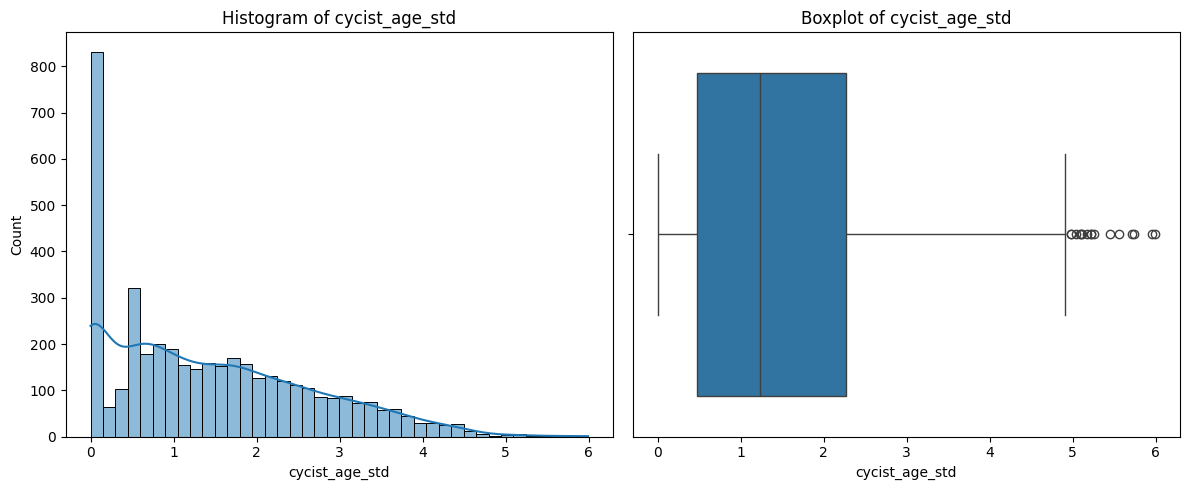

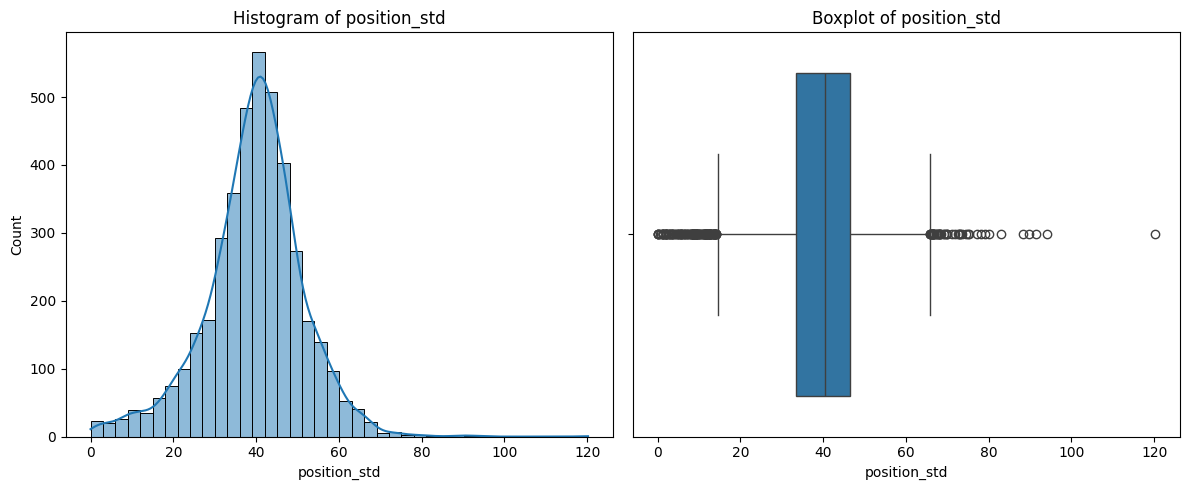

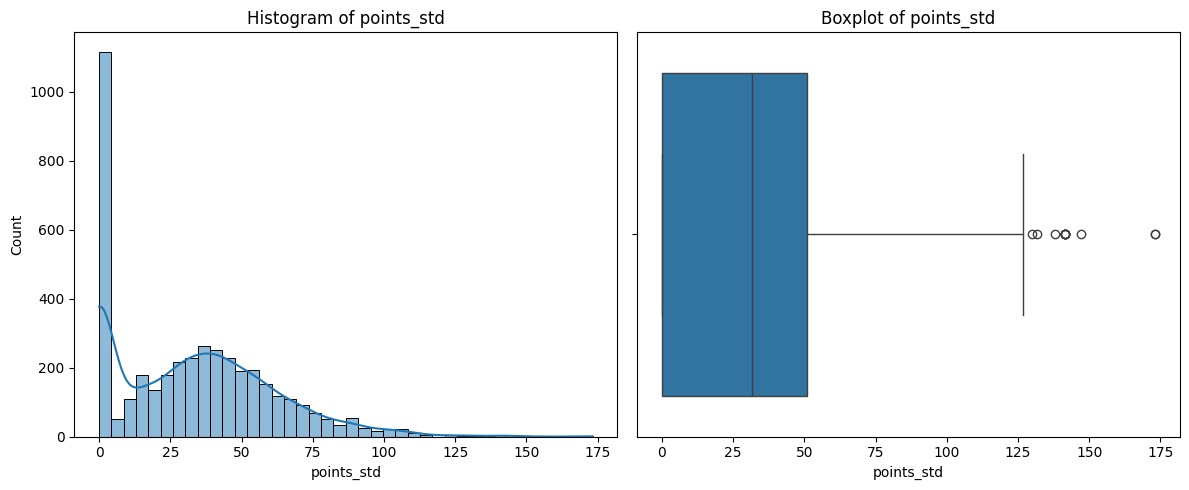

In [30]:
columns_to_select = cyclists.select_dtypes(include=[float, int])

for col in columns_to_select:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Histplot
    sns.histplot(cyclists[col].dropna(), bins=40, kde=True, edgecolor='black', ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')
    
    # Boxplot
    sns.boxplot(x=cyclists[col].dropna(), ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

- Let's print the 5 top cyclist according to 'adjusted_points'

In [31]:
top_cyclists = cyclists['adjusted_points'].sort_values(ascending=False).head(5)
print(cyclists.loc[top_cyclists.index, 'cyclist'])

99      alejandro-valverde
3463           peter-sagan
3489      philippe-gilbert
1615     greg-van-avermaet
4338       vincenzo-nibali
Name: cyclist, dtype: object


Outliers are mainly correlated to very performing cyclists (Wikipedia Links):
- [Alejandro-Valverde](https://it.wikipedia.org/wiki/Alejandro_Valverde)
- [Peter-Sagan](https://it.wikipedia.org/wiki/Peter_Sagan)
- [Philippe-Gilbert](https://it.wikipedia.org/wiki/Philippe_Gilbert)
- [Greg-Van-Avermaet](https://it.wikipedia.org/wiki/Greg_Van_Avermaet)
- [Vincenzo-Nibali](https://it.wikipedia.org/wiki/Vincenzo_Nibali)

We can work with this kind of cyclists or treat them as "extraordinary" cyclists and cut them out from the study.

- Put a threshold to adjusted_points and visualize.

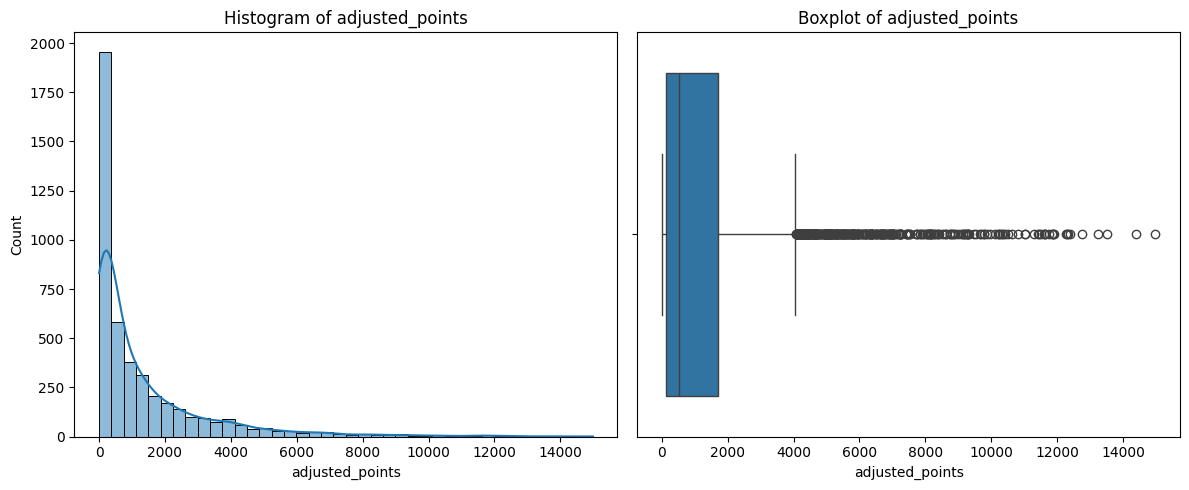

In [32]:
columns_to_select = ['adjusted_points']
tmp = cyclists[cyclists['adjusted_points'] < 15000]

for col in columns_to_select:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Histplot
    sns.histplot(tmp[col].dropna(), bins=40, kde=True, edgecolor='black', ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')
    
    # Boxplot
    sns.boxplot(x=tmp[col].dropna(), ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

In [33]:
import pickle
import gzip

save = True

if save:
    with gzip.open('cyclist_nf.pkl', 'wb') as file:
        pickle.dump(cyclists, file)